<a href="https://colab.research.google.com/github/ayukathisanda456-maker/Grad-Shafranov_simulations/blob/main/GS_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install freegs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.7/106.7 kB 1.3 MB/s eta 0:00:00


# Parametric Study of the Grad Shafranov Equation
The Grad-Shafranov equation is an equilibrium equation that for 2D plasma. The equation can be used to describe the GS shift. This whereby the plasma is pushed towards the edges of the reactor due to an increase in the poloidal beta(β). The GS equation is,



$ \huge{\Delta^* \psi  = -\mu_0R^2 \frac{dp}{d\psi} - \frac{1}{2}F \frac{dF}{d\psi} }$



*   ψ is the poloidal flux
*   $μ_0$ is the magnetic permeability
*   R is the radial distance
*   p is the pressure
*   F is a function
$ F = RB_\phi$ where $ B_ϕ $ is the toroidal magnetic field.







In this piece of work, the aim is to consider a fixed boundary simulation and then investigate the effect of the displacement of the o-point in the plasma(ΔR) as a function of the poliodal beta(β).

The GS equation is solved numerically by using the open source python library [FreeGS](https://github.com/freegs-plasma/freegs$0). We also adapt an example script in the documentation of FreeGS, that is linked [here](https://https://github.com/freegs-plasma/freegs/blob/master/05-fixed-boundary.py$0).

In [3]:
import freegs
import numpy as np
import matplotlib.pyplot as plt

#The following function is used to find the O- and X-points in the psi grid, which must be found for this project.
from freegs.critical import find_critical

#Boundary conditions
from freegs import boundary


We create a function that takes in necessary min and the max of necessary
values needed for the profiles.



*   We change the poloidal β, we have to increase peak pressure
*   The poloidal beta is given as $ β = \frac{\sum nkT}{\frac{B^2}{2μ_0}} $
*   The critical points are found, by finding the 'o-points', the o points are the maxima or the minima of the poloidal flux.
*   The ΔR is given as $ ΔR = R_{axis} - R_{geo}$ where $R_geo = \frac{R_{min} + R_{max}}{2} $.





In [5]:
def equlibriumGSsolution(Rmin, Rmax, Zmin, Zmax, nx, ny, maxPressure):
    eq = freegs.Equilibrium(
        Rmin=Rmin,
        Rmax=Rmax,
        Zmin=Zmin,
        Zmax=Zmax,
        nx=nx,
        ny=ny,
        boundary=boundary.fixedBoundary,
    )

    #We set the conditions for the plasma profiles, which are used to solve the Grad-Shafranov equation.
    #Our variable that is changed, is the maxPressure.

    profiles = freegs.jtor.ConstrainPaxisIp(
        eq,
        maxPressure,  # Plasma pressure on axis [Pascals]
        1e5,  # Plasma current [Amps]
        1.0,
    )  # fvac = R*Bt

    #Nonlinear solver for Grad-Shafranov equation
    freegs.solve(
        eq,  # The equilibrium to adjust
        profiles,  # The toroidal current profile function
        show=True,
    )

    #The r and x values of the O point need to be found, which is done using the find_critical function.
    R_values = eq.R #radial values of our grid(cylindrical coordinates)
    Z_values = eq.Z #z values of our grid(cylindrical coordinates)
    psi_values = eq.psi() #the psi values of our grid, which is the solution to the Grad-Shafranov equation(Poloidal flux).

    opoints, xpoints = find_critical(R_values, Z_values, psi_values, discard_xpoints=True)
    if len(opoints) == 0:
        raise RuntimeError("No O-points found in psi grid")
    r_axis, z_axis, psi_axis = opoints[0]

    #We also need to determine the polodial beta, which can be retrived from the our solution.
    poloidal_beta = eq.poloidalBeta()

    R_geo = (Rmin+Rmax)/2

    return (r_axis-R_geo), z_axis, poloidal_beta


Now using the above created function, we loop through maximum pressures between $1 × 10^3 $ and $ 1 × 10^4 $ and find the ΔR as function of the poloidal beta, β.

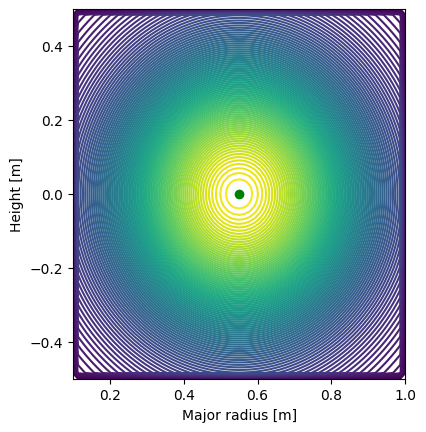

/usr/local/lib/python3.12/dist-packages/freegs/picard.py:177: RuntimeWarning: invalid value encountered in scalar divide
  bndry_relchange = abs(bndry_change / bndry)


psi_relchange: 117.22652115650638
bndry_relchange: nan
bndry_change: 0.0


psi_relchange: 0.2877579089766433
bndry_relchange: nan
bndry_change: 0.0


psi_relchange: 0.1002728828543091
bndry_relchange: nan
bndry_change: 0.0


psi_relchange: 0.047068455619858084
bndry_relchange: nan
bndry_change: 0.0


psi_relchange: 0.023831868338053883
bndry_relchange: nan
bndry_change: 0.0


psi_relchange: 0.012525606349355218
bndry_relchange: nan
bndry_change: 0.0


psi_relchange: 0.006691792588896648
bndry_relchange: nan
bndry_change: 0.0


psi_relchange: 0.003619592042246705
bndry_relchange: nan
bndry_change: 0.0


psi_relchange: 0.0019722030169819103
bndry_relchange: nan
bndry_change: 0.0


psi_relchange: 0.0010789826132078964
bndry_relchange: nan
bndry_change: 0.0


psi_relchange: 0.0005919074126076379
bndry_relchange: nan
bndry_change: 0.0




/usr/local/lib/python3.12/dist-packages/freegs/jtor.py:66: IntegrationWarning: Extremely bad integrand behavior occurs at some points of the
  integration interval.
  val, _ = quad(self.pprime, pvals[i], 1.0)


Pressure on axis: 1000.0 Pa, Poloidal beta: 0.15504420059058296


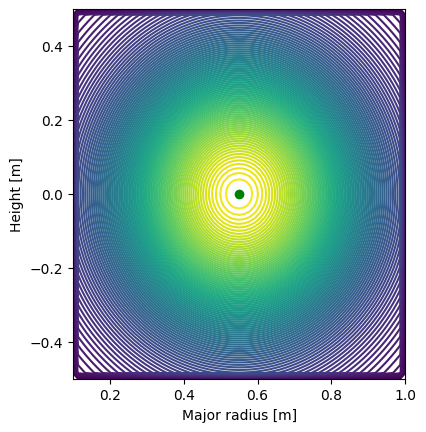

psi_relchange: 117.01589942130533
bndry_relchange: nan
bndry_change: 0.0


psi_relchange: 0.41410239145767014
bndry_relchange: nan
bndry_change: 0.0


psi_relchange: 0.08726941298351311
bndry_relchange: nan
bndry_change: 0.0


psi_relchange: 0.03994548834037594
bndry_relchange: nan
bndry_change: 0.0


psi_relchange: 0.018008601769291126
bndry_relchange: nan
bndry_change: 0.0


psi_relchange: 0.008285895896112573
bndry_relchange: nan
bndry_change: 0.0


psi_relchange: 0.003815110976046436
bndry_relchange: nan
bndry_change: 0.0


psi_relchange: 0.0017651680426943827
bndry_relchange: nan
bndry_change: 0.0


psi_relchange: 0.0008160392179571906
bndry_relchange: nan
bndry_change: 0.0


Pressure on axis: 3250.0 Pa, Poloidal beta: 0.44161849181637813


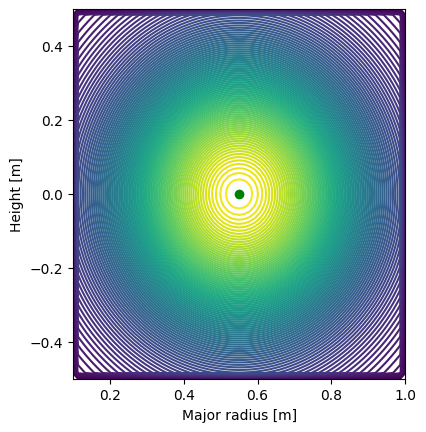

psi_relchange: 116.80602888002187
bndry_relchange: nan
bndry_change: 0.0


psi_relchange: 0.5070204859941521
bndry_relchange: nan
bndry_change: 0.0


psi_relchange: 0.08690705136982753
bndry_relchange: nan
bndry_change: 0.0


psi_relchange: 0.040278442980169894
bndry_relchange: nan
bndry_change: 0.0


psi_relchange: 0.017641332024068677
bndry_relchange: nan
bndry_change: 0.0


psi_relchange: 0.007846706939619507
bndry_relchange: nan
bndry_change: 0.0


psi_relchange: 0.0034595915448417244
bndry_relchange: nan
bndry_change: 0.0


psi_relchange: 0.001502161531580251
bndry_relchange: nan
bndry_change: 0.0


psi_relchange: 0.0006433505644051172
bndry_relchange: nan
bndry_change: 0.0


Pressure on axis: 5500.0 Pa, Poloidal beta: 0.6678919976117643


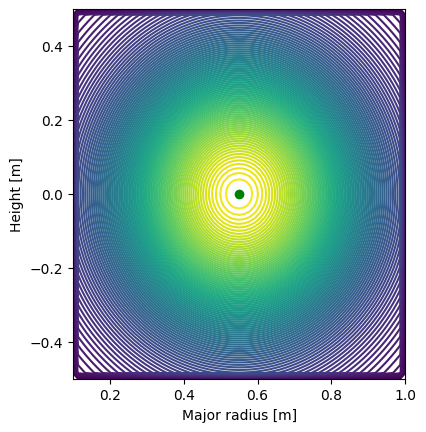

psi_relchange: 116.59690552081601
bndry_relchange: nan
bndry_change: 0.0


psi_relchange: 0.5751859599709301
bndry_relchange: nan
bndry_change: 0.0


psi_relchange: 0.16727476850596876
bndry_relchange: nan
bndry_change: 0.0


psi_relchange: 0.05078919454911525
bndry_relchange: nan
bndry_change: 0.0


psi_relchange: 0.018774434785279133
bndry_relchange: nan
bndry_change: 0.0


psi_relchange: 0.008604817503512233
bndry_relchange: nan
bndry_change: 0.0


psi_relchange: 0.003742232216298399
bndry_relchange: nan
bndry_change: 0.0


psi_relchange: 0.001591327300186436
bndry_relchange: nan
bndry_change: 0.0


psi_relchange: 0.0006513701685085512
bndry_relchange: nan
bndry_change: 0.0


Pressure on axis: 7750.0 Pa, Poloidal beta: 0.8557866540201806


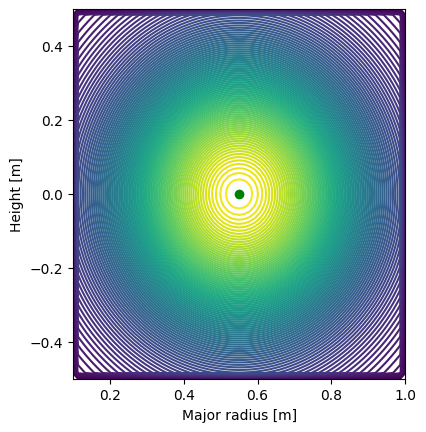

psi_relchange: 116.38852536000852
bndry_relchange: nan
bndry_change: 0.0


psi_relchange: 0.6274585288923377
bndry_relchange: nan
bndry_change: 0.0


psi_relchange: 0.26829978745117705
bndry_relchange: nan
bndry_change: 0.0


psi_relchange: 0.06723538862389145
bndry_relchange: nan
bndry_change: 0.0


psi_relchange: 0.018587065693522895
bndry_relchange: nan
bndry_change: 0.0


psi_relchange: 0.009935643361750858
bndry_relchange: nan
bndry_change: 0.0


psi_relchange: 0.004183814242938497
bndry_relchange: nan
bndry_change: 0.0


psi_relchange: 0.0017919889099258569
bndry_relchange: nan
bndry_change: 0.0


psi_relchange: 0.0007030634952541107
bndry_relchange: nan
bndry_change: 0.0


Pressure on axis: 10000.0 Pa, Poloidal beta: 1.0174573301817853


In [6]:
pressure_values = np.linspace(1e3, 1e4, 5) #We want to vary the pressure on axis from 1e4 to 1e5 Pascals,
#which is done using the linspace function.

#We define the values required for our profiles in the GD solver.
R_min = 0.1
R_max = 1.0
Z_min = -0.5
Z_max = 0.5
nx = 65
ny = 65


opointRvalues = []
Betavalues = []


#We loop through different max pressure values, that as a result changes the poloidal beta
for pressure in pressure_values:
    R,Z,Beta = equlibriumGSsolution(R_min, R_max, Z_min, Z_max, nx, ny, pressure)

    #Append retrieved values to lists of \deltaR and \beta values.
    opointRvalues.append(R)
    Betavalues.append(Beta)

    print(f"Pressure on axis: {pressure} Pa, Poloidal beta: {Beta}")



We plot the ΔR as a function of poloidal \beta.


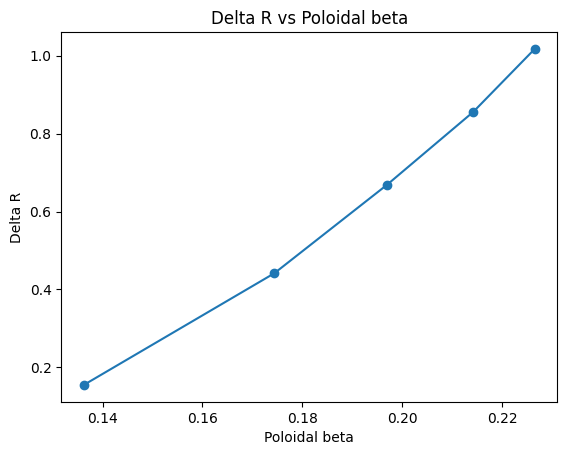

In [7]:
plt.plot(opointRvalues, Betavalues, marker='o')
plt.xlabel('Poloidal beta')
plt.ylabel('Delta R/m')
plt.title('Delta R vs Poloidal beta')
plt.show()
